# Python Project

### Importing necessary librarys

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Preprocessing:
Correct the data in the "height" column by replacing it with random numbers between 150 and 180. Ensure data consistency and integrity before proceeding with analysis

In [5]:
Teams = pd.read_excel("myexcel.xlsx")                                       ## Inporting excel file
Teams['Salary'] = Teams['Salary'].fillna('0')                               ## replaces NaN value to 0 in salary column
Teams['Salary'] = Teams['Salary'].apply(int)                                ## converts salary column object to int
Teams['Salary'] = Teams['Salary'].replace(0,(int(Teams['Salary'].mean())))  ## Replacing 0 value to avarage of Salary
Teams = Teams.fillna('')                                                    ## replace NaN value with empty
Teams = Teams.drop_duplicates()                                             ## removes any duplicate row
Teams["Height"] = np.random.randint(150,160+1,len(Teams))                   ## replacing with random numbers between 150 and 180 for Height column
Teams.head(5)

,Name,Team,Number,Position,Age,Height,Weight,College,Salary
0,Avery Bradley,Boston Celtics,0,PG,25,159,180,Texas,7730337
1,Jae Crowder,Boston Celtics,99,SF,25,152,235,Marquette,6796117
2,John Holland,Boston Celtics,30,SG,27,156,205,Boston University,4717869
3,R.J. Hunter,Boston Celtics,28,SG,22,150,185,Georgia State,1148640
4,Jonas Jerebko,Boston Celtics,8,PF,29,159,231,,5000000


### Analysis Tasks:

### 1.Determine the distribution of employees across each team and calculate the percentage split relative to the total number of employees

In [8]:
team_counts = Teams['Team'].value_counts()                                # Group by team and count employees
total_els = len(Teams)                                                    # Calculate total employees
percentage_split = (team_counts/total_els) * 100                          # Calculate Percentage Split

## Create a new DataFrame with team, count, and percentage ##
team_distribution = pd.DataFrame({'Team': team_counts.index, 
                                 'Count': team_counts.values, 
                                 'Percentage': percentage_split.values})
team_distribution.head(3)

,Team,Count,Percentage
0,New Orleans Pelicans,19,4.148472
1,Memphis Grizzlies,18,3.930131
2,Utah Jazz,16,3.493450


#### Ploting for distribution of employees across each team

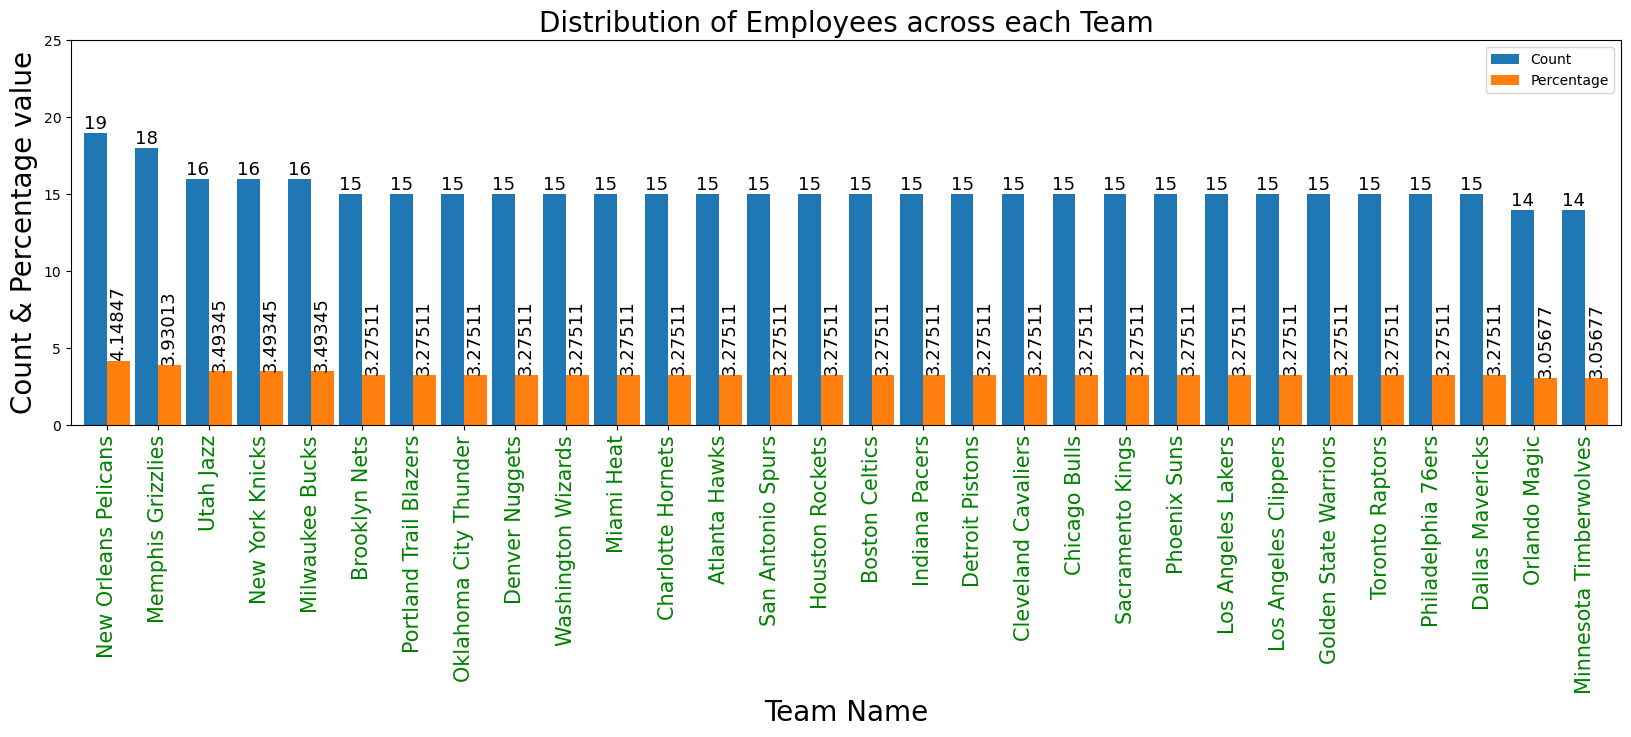

In [10]:
ax=team_distribution.plot.bar(x='Team',stacked=False,width=0.9,figsize=(20,5))
plt.ylim(top=25) 
plt.ylim(bottom=0)
plt.title("Distribution of Employees across each Team",size = 20)
plt.xticks(size=15,color ='g')
plt.xlabel('Team Name',size = 20)
plt.ylabel('Count & Percentage value',size = 20)
ax.bar_label(ax.containers[0], label_type='edge',size = 13)
ax.bar_label(ax.containers[1], label_type='edge',rotation=90,size = 13)
plt.show()

### 2. Segregate employees based on their positions within the company

In [12]:
# Segregate employees based on their positions
grouped_Teams = Teams.groupby(['Position']).agg({'Name': 'nunique','Team':'nunique',})
grouped_Teams

,Name,Team
Position,,
C,79,30
PF,100,30
PG,92,30
SF,85,29
SG,102,30


#### Ploting Segregation of employees based on their positions

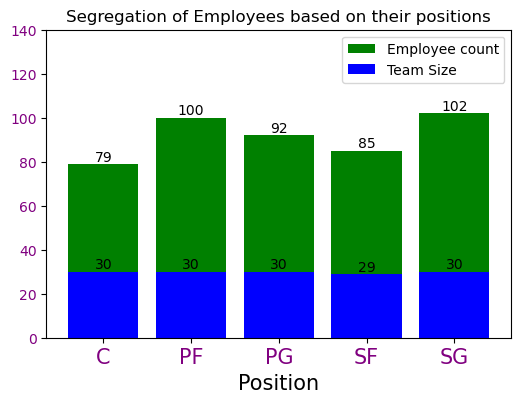

In [14]:
plt.ylim(top=140) 
plt.ylim(bottom=0)
ax=grouped_Teams['Name'].plot.bar(stacked=True,figsize=(6,4),color ="g",label='Employee count',width=0.8,legend=True)
ax=grouped_Teams['Team'].plot.bar(stacked=True,figsize=(6,4),color ="b",label='Team Size',width=0.8,legend=True)
plt.xticks(rotation=360,size=15,color ='purple')
plt.yticks(size=10,color ='purple')
ax.bar_label(ax.containers[0], label_type='edge')
ax.bar_label(ax.containers[1], label_type='edge')
plt.title("Segregation of Employees based on their positions",size = 12)
plt.xlabel('Position',size = 15)
plt.grid(False)
plt.show()

### 3. Identify the predominant age group among employees. 

In [16]:
grouped_Age = Teams.groupby(['Age']).agg({'Name': 'nunique'})
grouped_Age.head(5)

,Name
Age,
19,2
20,19
21,19
22,26
23,41


### Ploting Age Group among Employees

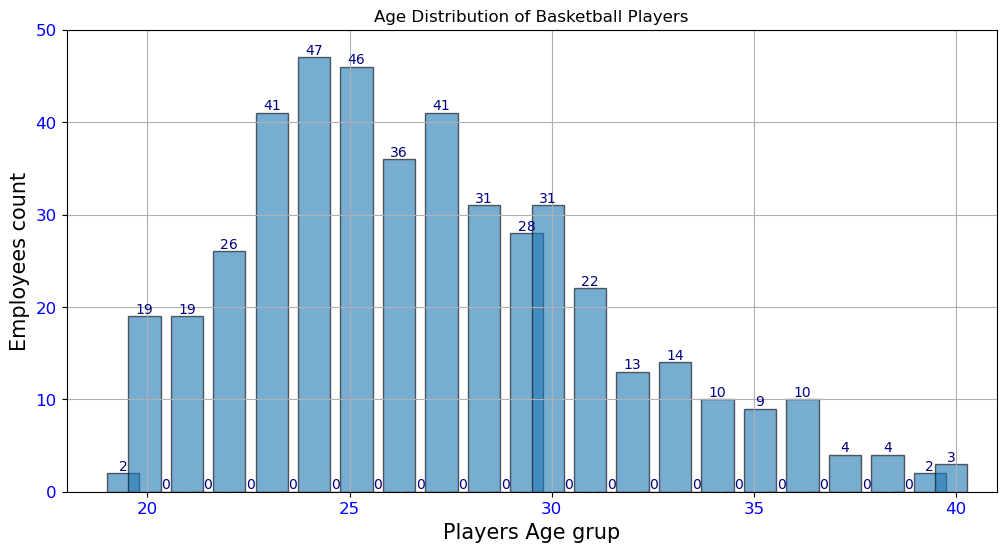

In [18]:
plt.figure(figsize=(12, 6))
plt.ylim(top=50) 
plt.ylim(bottom=0)
plt.xlim(18,41) 
ax=plt.hist(Teams['Age'], bins=40,edgecolor='black',width=.8,alpha=.6,bottom=None)
plt.bar_label(ax[2],fontsize=10, color='navy' )
plt.xticks(rotation=360,size=12,color ='b')
plt.yticks(size=12,color ='b')
plt.xlabel('Players Age grup',size = 15)
plt.ylabel('Employees count',size = 15)
plt.title('Age Distribution of Basketball Players')
plt.grid(True)
plt.show()

### 4. Discover which team and position have the highest salary expenditure

In [20]:
grouped_df = Teams.groupby(['Team'])['Salary'].sum()
Hig_exp_tem = grouped_df.idxmax()
Hig_exp_amount = grouped_df.max()
print(f'\033[1mHighest expenditure team is "{Hig_exp_tem}" and Hig expenditure Amount is "{Hig_exp_amount}"\033[1m')
grouped_df = pd.DataFrame(grouped_df)
grouped_df.head(5)

Highest expenditure team is "Cleveland Cavaliers" and Hig expenditure Amount is "111706558"


,Salary
Team,
Atlanta Hawks,72902950
Boston Celtics,63258937
Brooklyn Nets,52528475
Charlotte Hornets,78340920
Chicago Bulls,86783378


### Ploting Highest expenditure Team

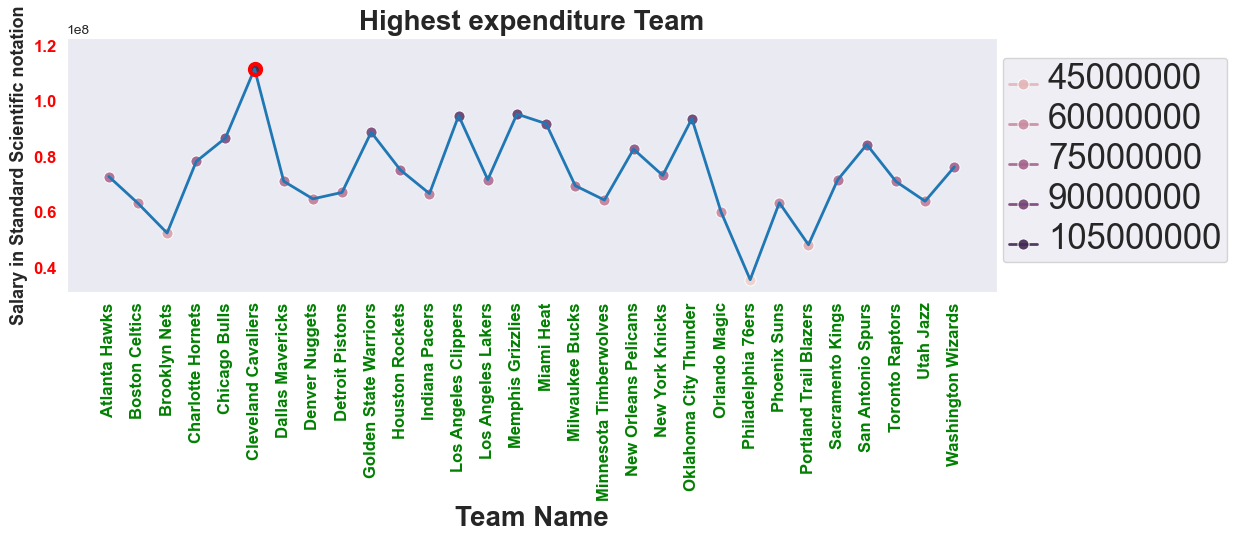

In [22]:
sns.set_style('dark')
plt.figure(figsize=(12, 3.3))
plt.title('Highest expenditur team')
lpts=sns.lineplot(data= grouped_df, x='Team', y='Salary', marker='o', markersize=8,hue='Salary',lw=2,legend='auto',alpha=.9)
sns.lineplot(data= grouped_df, x='Team', y='Salary',linewidth=2)
lpts.plot(Hig_exp_tem, Hig_exp_amount, marker= "$\\circ$", color="r", markersize=10)
lpts.set_ylim(top=122706558)
lpts.set_ylim(bottom=31100000)
lpts.set_ylabel("Salary in Standard Scientific notation",fontsize=13,weight='bold')
lpts.set_xlabel("Team Name",fontsize=20,weight='bold')
lpts.set_title('Highest expenditure Team',fontsize=20,weight='bold')
sns.move_legend(lpts, "upper left", bbox_to_anchor=(1,.9509))
plt.setp(lpts.get_legend().get_texts(), fontsize='25') # for legend text
plt.setp(lpts.get_legend().get_title(), fontsize='32') # for legend title
plt.xticks(size=12,weight='bold',color ='green',rotation = 90)
plt.yticks(size=12,weight='bold',color ='red')
plt.show()

### 5. Investigate if there's any correlation between age and salary, and represent it visually

In [24]:
# Computing the correlation between Age and Salary
corr_Teams =Teams[['Age','Salary']]
correlation = corr_Teams.corr()
correlation

,Age,Salary
Age,1.000000,0.211071
Salary,0.211071,1.000000


### Ploting Heat map for correlation 

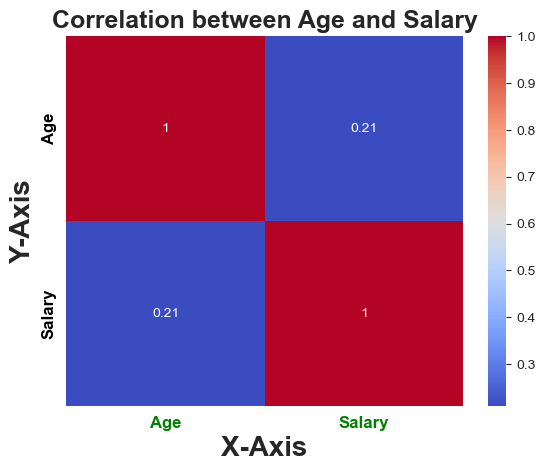

In [26]:
heatm=sns.heatmap(correlation,annot=True, cmap='coolwarm')
heatm.set_ylabel("Y-Axis",fontsize=20,weight='bold')
heatm.set_xlabel("X-Axis",fontsize=20,weight='bold')
heatm.set_title('Correlation between Age and Salary',fontsize=18,weight='bold')
plt.xticks(size=12,weight='bold',color ='green')
plt.yticks(size=12,weight='bold',color ='black')
plt.show()